## Problem Statement


## Objective

## Implementation 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"D:\Project\statistics - taxi fare analysis and comparison\2023_Yellow_Taxi_Trip_Data.csv")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [4]:
# Drop the unnecessary columns
df = df.drop(columns=[
    'VendorID', 'RatecodeID', 'store_and_fwd_flag', 
    'PULocationID', 'DOLocationID', 'extra', 
    'total_amount', 'tip_amount', 'tolls_amount', 
    'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 
    'mta_tax'
])

In [5]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount
0,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,2,9.30
1,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.10,1,7.90
2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1,14.90
3,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.90,1,12.10
4,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1,11.40
...,...,...,...,...,...,...
38310221,12/31/2023 11:04:34 PM,12/31/2023 11:13:58 PM,NaN,1.34,0,12.08
38310222,12/31/2023 11:08:15 PM,12/31/2023 11:08:23 PM,NaN,0.00,0,25.98
38310223,12/31/2023 11:16:15 PM,12/31/2023 11:30:28 PM,NaN,3.71,0,16.68
38310224,12/31/2023 11:21:58 PM,12/31/2023 11:34:29 PM,NaN,5.20,0,19.64


In [6]:
df.drop_duplicates(inplace=True) ##drop duplicate rows

In [7]:
df.dropna(inplace= True) ##drop null values

In [8]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount
0,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,2,9.3
1,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.10,1,7.9
2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1,14.9
3,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.90,1,12.1
4,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1,11.4
...,...,...,...,...,...,...
38130218,12/31/2023 11:03:46 PM,12/31/2023 11:21:54 PM,1.0,2.60,1,17.0
38130219,12/31/2023 11:23:34 PM,12/31/2023 11:26:17 PM,1.0,0.60,1,5.1
38130220,12/31/2023 11:34:58 PM,12/31/2023 11:53:01 PM,1.0,3.80,1,19.8
38130221,12/31/2023 11:12:45 PM,12/31/2023 11:23:15 PM,2.0,3.10,1,14.9


In [9]:
df.dtypes

tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
payment_type               int64
fare_amount              float64
dtype: object

In [10]:
##convert datatype to int
df['passenger_count']=df['passenger_count'].astype('int64')
df['payment_type']=df['payment_type'].astype('int64')

In [11]:
df['payment_type']=df['payment_type'].astype('int64')

In [12]:
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.751969
2    0.151592
3    0.037694
4    0.021350
0    0.015757
5    0.013060
6    0.008567
8    0.000007
7    0.000003
9    0.000001
Name: proportion, dtype: float64

In [14]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount
0,08/31/2023 11:27:45 AM,08/31/2023 11:32:43 AM,0,0.60,3,6.5
1,10/18/2023 06:35:11 AM,10/18/2023 07:03:08 AM,1,3.70,1,24.0
2,12/28/2023 06:32:22 PM,12/28/2023 06:51:34 PM,1,2.77,1,18.4
3,06/05/2023 12:53:32 PM,06/05/2023 01:20:55 PM,1,3.30,1,22.6
4,12/14/2023 10:36:41 AM,12/14/2023 11:10:44 AM,1,10.64,1,50.6
...,...,...,...,...,...,...
11099703,06/29/2023 05:46:15 PM,06/29/2023 06:15:48 PM,2,2.84,1,25.4
11099704,09/18/2023 06:30:30 AM,09/18/2023 07:04:14 AM,1,6.07,1,33.8
11099705,04/30/2023 08:13:13 AM,04/30/2023 08:18:07 AM,1,0.74,2,6.5
11099706,04/22/2023 12:40:11 AM,04/22/2023 12:42:52 AM,1,0.73,1,5.8


Find the duration using the pickup and dropoff time

In [15]:
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])

In [16]:
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

In [17]:
df.dtypes

tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
payment_type                      int64
fare_amount                     float64
dtype: object

In [18]:
df['duration']=df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']
df['duration']=df['duration'].dt.total_seconds()/60 ## total number of minutes 
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,duration
0,2023-08-31 11:27:45,2023-08-31 11:32:43,0,0.60,3,6.5,4.966667
1,2023-10-18 06:35:11,2023-10-18 07:03:08,1,3.70,1,24.0,27.950000
2,2023-12-28 18:32:22,2023-12-28 18:51:34,1,2.77,1,18.4,19.200000
3,2023-06-05 12:53:32,2023-06-05 13:20:55,1,3.30,1,22.6,27.383333
4,2023-12-14 10:36:41,2023-12-14 11:10:44,1,10.64,1,50.6,34.050000
...,...,...,...,...,...,...,...
11099703,2023-06-29 17:46:15,2023-06-29 18:15:48,2,2.84,1,25.4,29.550000
11099704,2023-09-18 06:30:30,2023-09-18 07:04:14,1,6.07,1,33.8,33.733333
11099705,2023-04-30 08:13:13,2023-04-30 08:18:07,1,0.74,2,6.5,4.900000
11099706,2023-04-22 00:40:11,2023-04-22 00:42:52,1,0.73,1,5.8,2.683333


In [19]:
# Drop the unnecessary columns
df = df.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

In [20]:
df=df[df['payment_type']<3]
df=df[(df['passenger_count']>0)&(df['passenger_count']<6)]

In [21]:
df.shape

(10613459, 5)

In [22]:
df['payment_type'].replace([1,2],['Card','Cash'],inplace = True)

In [23]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,1.061346e+07,1.061346e+07,1.061346e+07,1.061346e+07
mean,1.352174e+00,3.580951e+00,1.975931e+01,1.748895e+01
std,7.734315e-01,4.738421e+01,1.950393e+01,4.144998e+01
min,1.000000e+00,0.000000e+00,-7.000000e+02,-4.762500e+02
25%,1.000000e+00,1.060000e+00,9.300000e+00,7.666667e+00
50%,1.000000e+00,1.800000e+00,1.350000e+01,1.261667e+01
75%,1.000000e+00,3.400000e+00,2.190000e+01,2.061667e+01
max,5.000000e+00,7.322380e+04,1.915290e+04,1.002918e+04


In [24]:
df=df[df['fare_amount']>0]
df=df[df['trip_distance']>0]
df=df[df['duration']>0]

In [25]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
1,1,3.70,Card,24.0,27.950000
2,1,2.77,Card,18.4,19.200000
3,1,3.30,Card,22.6,27.383333
4,1,10.64,Card,50.6,34.050000
5,1,0.30,Cash,5.1,2.550000
...,...,...,...,...,...
11099703,2,2.84,Card,25.4,29.550000
11099704,1,6.07,Card,33.8,33.733333
11099705,1,0.74,Cash,6.5,4.900000
11099706,1,0.73,Card,5.8,2.683333


In [26]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,1.047785e+07,1.047785e+07,1.047785e+07,1.047785e+07
mean,1.352032e+00,3.617735e+00,1.973544e+01,1.755449e+01
std,7.732269e-01,4.768751e+01,1.802769e+01,4.120494e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.090000e+00,9.300000e+00,7.750000e+00
50%,1.000000e+00,1.800000e+00,1.350000e+01,1.268333e+01
75%,1.000000e+00,3.420000e+00,2.190000e+01,2.065000e+01
max,5.000000e+00,7.322380e+04,1.375000e+03,5.501717e+03


{'whiskers': [<matplotlib.lines.Line2D at 0x1df253bbc50>,
 'caps': [<matplotlib.lines.Line2D at 0x1df253bbed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1df24fa7ed0>],
 'medians': [<matplotlib.lines.Line2D at 0x1df253d8190>],
 'fliers': [<matplotlib.lines.Line2D at 0x1df253d82d0>],
 'means': []}

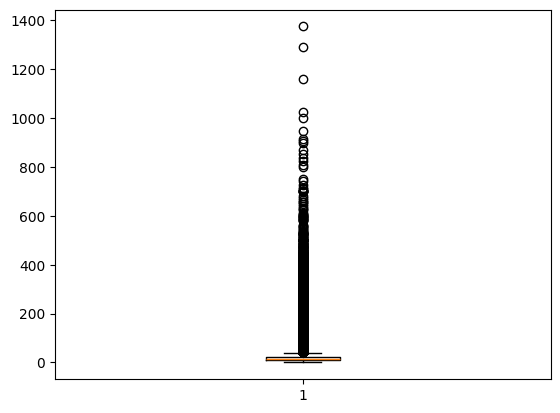

In [28]:
#check for outliers
plt.boxplot(df['fare_amount'])

In [30]:
#remove outliers
for col in ['fare_amount','trip_distance','duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1-1.5*IQR
    upper_bound =  q3+1.5*IQR
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]

In [31]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
1,1,3.70,Card,24.0,27.950000
2,1,2.77,Card,18.4,19.200000
3,1,3.30,Card,22.6,27.383333
5,1,0.30,Cash,5.1,2.550000
6,1,0.83,Card,7.2,5.250000
...,...,...,...,...,...
11099702,1,1.00,Card,15.6,17.333333
11099703,2,2.84,Card,25.4,29.550000
11099705,1,0.74,Cash,6.5,4.900000
11099706,1,0.73,Card,5.8,2.683333


In [32]:
df.to_csv("D:\Project\statistics - taxi fare analysis and comparison\Taxi_Trip_Data_preprocessed.csv", index=False)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [13]:
df=pd.read_csv(r"D:\Project\statistics - taxi fare analysis and comparison\Taxi_Trip_Data_preprocessed.csv")

In [3]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,3.70,Card,24.0,27.950000
1,1,2.77,Card,18.4,19.200000
2,1,3.30,Card,22.6,27.383333
3,1,0.30,Cash,5.1,2.550000
4,1,0.83,Card,7.2,5.250000
...,...,...,...,...,...
8451085,1,1.00,Card,15.6,17.333333
8451086,2,2.84,Card,25.4,29.550000
8451087,1,0.74,Cash,6.5,4.900000
8451088,1,0.73,Card,5.8,2.683333


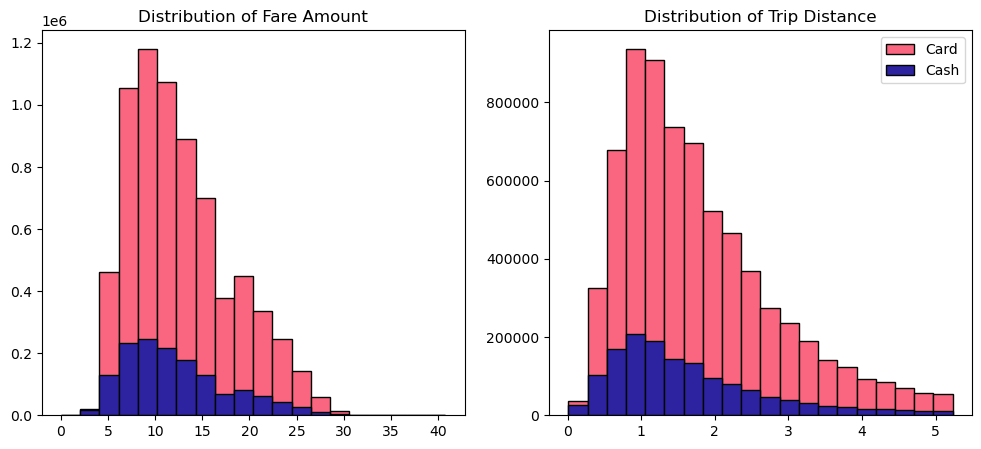

In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of Fare Amount')
plt.hist(df[df['payment_type']=='Card']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#FA657F',label='Card')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#2D23A1',label='Cash')

plt.subplot(1,2,2)
plt.title('Distribution of Trip Distance')
plt.hist(df[df['payment_type']=='Card']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#FA657F',label='Card')
plt.hist(df[df['payment_type']=='Cash']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#2D23A1',label='Cash')
plt.legend()
plt.show()

In [5]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'], 'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           12.835714  5.339924      1.775855  1.043258
Cash           12.227121  5.351502      1.631084  1.047995

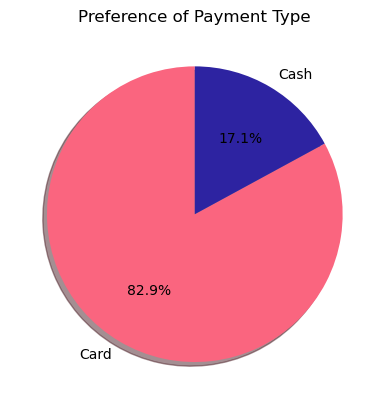

In [6]:
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize = True),labels = df['payment_type'].value_counts().index,startangle=90,shadow=True,autopct='%1.1f%%',colors=['#FA657F','#2D23A1'])
plt.show()

In [19]:
df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()

passenger_count
payment_type passenger_count                 
Card         1                        5513741
             2                        1020778
             3                         251933
             4                         125180
             5                          96456
Cash         1                        1074081
             2                         238282
             3                          64950
             4                          45061
             5                          20628

In [24]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count':'count'},inplace=True)
passenger_count.reset_index(inplace=True)

In [26]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100

In [28]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,5513741,65.242957
1,Card,2,1020778,12.078655
2,Card,3,251933,2.981071
3,Card,4,125180,1.481229
4,Card,5,96456,1.141344
5,Cash,1,1074081,12.709378
6,Cash,2,238282,2.819542
7,Cash,3,64950,0.768540
8,Cash,4,45061,0.533197
9,Cash,5,20628,0.244087


In [34]:
df=pd.DataFrame(columns=['payment_type',1,2,3,4,5])
df['payment_type']=['Card','Cash']
df.iloc[0,1:]=passenger_count.iloc[0:5,-1]
df.iloc[1,1:]=passenger_count.iloc[5:,-1]
df

,payment_type,1,2,3,4,5
0,Card,65.242957,12.078655,2.981071,1.481229,1.141344
1,Cash,12.709378,2.819542,0.76854,0.533197,0.244087


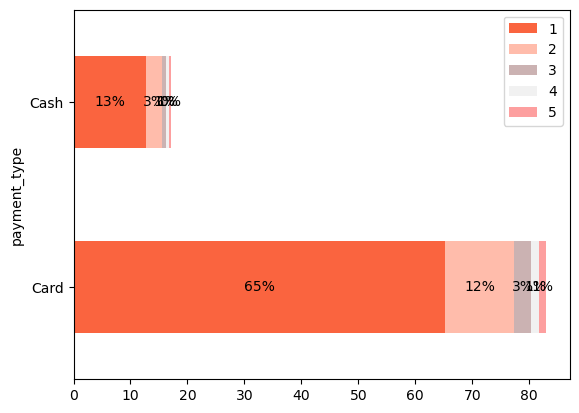

In [46]:
ax=df.plot(x='payment_type',kind='barh',stacked=True,color=['#FA643F','#FFBCAB','#CBB2B2','#F1F1F1','#FD9F9F'])

#Add percentage text
for p in ax.patches:
    width=p.get_width()
    height=p.get_height()
    x,y=p.get_xy()
    ax.text(x+width/2,y+height/2,'{:.0f}%'.format(width),horizontalalignment='center',verticalalignment='center')

Null Hypothesis: There is no difference in average fare between customers who use credit cards and customers who use cash

Alternative Hypothesis: There is a difference in average fare between customers who use credit cards and customers who use cash

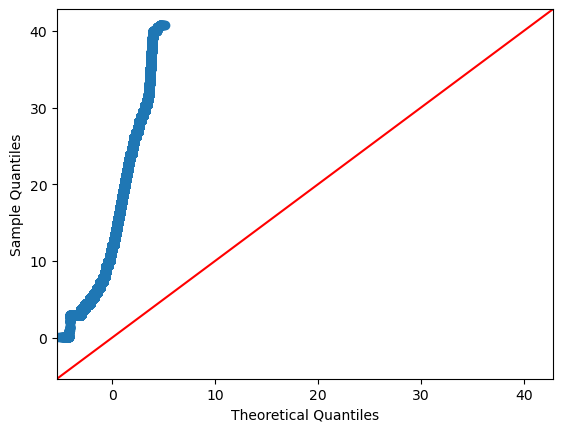

In [21]:
sm.qqplot(df['fare_amount'],line='45')
plt.show()

In [25]:
card_sample = df[df['payment_type']=='Card']['fare_amount']
cash_sample = df[df['payment_type']=='Cash']['fare_amount']

In [29]:
t_stats,p_value = st.ttest_ind(a = card_sample, b = cash_sample, equal_var = False)
print('T statistic', t_stats, 'p-value', p_value)

T statistic 124.44832710988426 p-value 0.0
